In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [35]:
os.makedirs("outputs", exist_ok=True)
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## **Tensor Question 1**

In [36]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

print(a, a.shape, a.dtype, a.device)
print(b, b.shape, b.dtype, b.device)
print(c, c.shape, c.dtype, c.device)

# What device are these tensors on right now? CPU
# If you were running a training loop on the GPU, why would it matter that your model weights and your input tensors are on the same device?
# During GPU training, model weights and inputs must be on the same device; otherwise, operations will fail or be inefficient due to data transfers.

tensor([[1., 2., 3.],
        [4., 5., 6.]]) torch.Size([2, 3]) torch.float32 cpu
tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32 cpu
tensor([1., 1., 1., 1.]) torch.Size([4]) torch.float32 cpu


## **Tensor Question 2**

In [37]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

# Compute and print the element-wise square root using torch.sqrt().
print("sqrt:", torch.sqrt(x))

# Compute and print the sum using .sum().
print("sum:", x.sum())
# Compute and print the mean using .mean().
print("mean:", x.mean())
# Find and print the index of the maximum value using .argmax().
print("argmax:", x.argmax())

# .argmax() appears in nearly every inference example you'll encounter. 
# In the context of a classifier that outputs scores for 1,000 classes, 
# what does .argmax() give you?
# Answer: 
# .argmax() returns the index of the highest value in the tensor.
# In a 1,000-class classifier, the network produces 1,000 scores (one for each class).
# .argmax() returns the index of the class with the highest score, that is the model's prediction.

sqrt: tensor([1., 2., 3., 4., 5.])
sum: tensor(55.)
mean: tensor(11.)
argmax: tensor(4)


## **Tensor Question 3**

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# Why does PyTorch require .cpu() before you can call .numpy()? 
# What does this tell you about where NumPy arrays live?
# Answer: 
# NumPy can only work with memory on the CPU.
# If the tensor is on the GPU, the data resides in GPU memory, and NumPy cannot access it.
# .cpu() moves the tensor back to CPU memory, where NumPy can operate on it.

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## **Tensor Question 4**

In [39]:
t = torch.arange(24).float()

# Reshape to (4, 6)
t1 = t.view(4, 6)
print("t1 shape:", t1.shape)

# Reshape to (2, 3, 4)
t2 = t.view(2, 3, 4)
print("t2 shape:", t2.shape)

# Add new dimension at position 0
t3 = t1.unsqueeze(0)
print("t3 shape:", t3.shape)

# A single image tensor typically has shape (channels, height, width). 
# Neural networks expect batches with shape (batch_size, channels, height, width). 
# What operation accomplishes this when you are processing one image at a time, and why does it matter?
# Answer:
# The operation is .unsqueeze(0), which adds a dimension at position 0.
# Neural networks expect batches: (batch_size, C, H, W).
# When processing a single image, .unsqueeze(0) converts it from (C, H, W) to (1, C, H, W),
# simulating a batch of size 1 to ensure compatibility with the model.

t1 shape: torch.Size([4, 6])
t2 shape: torch.Size([2, 3, 4])
t3 shape: torch.Size([1, 4, 6])


## **Tensor Question 5**

In [40]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

# NumPy matrix multiplication
np_result = np_a @ np_b
print("NumPy result:\n", np_result)

# PyTorch matrix multiplication
torch_result = t_a @ t_b
print("\nPyTorch result:\n", torch_result)

# Confirm they match
print("\nMatch:", np.allclose(np_result, torch_result.numpy()))

# At a high level, what role does matrix multiplication play as data passes through a single layer of a neural network?
# Answer:
# In a neural network layer, each neuron calculates a weighted sum of its inputs.
# This is equivalent to matrix multiplication: input @ weights.
# The result is the set of activations that pass to the next layer.

NumPy result:
 [[19. 22.]
 [43. 50.]]

PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])

Match: True


# **Pretrained Models**
## **Model Question 1**

In [41]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ResNet18 has roughly 11 million parameters. Training it from scratch required approximately 
# 1.2 million labeled ImageNet images and days of multi-GPU compute. 
# What does that tell you about the practical value of starting from pretrained weights when you're on a deadline or a budget?
# Answer: 
# Starting from pretrained weights is a perfect starting point becuase the learned useful features from a massive dataset like ImageNet.
# Training from scratch would require huge data and compute, so using pretrained weights saves time and resources, 
# especially under deadlines or limited budgets.

Total parameters:     11,689,512
Trainable parameters: 11,689,512


## **Model Question 2**

In [42]:
print(model)

# 1. What is the name of the final layer in ResNet18, and what is its output size? 
#(This number is the total count of ImageNet categories the model can predict.)
# Answer:
# The final layer is "fc" (fully connected), and its output size is 1000, which corresponds to the 1000 ImageNet classes.
# 2. Can you identify the blocks named layer1 through layer4? These are the "deep" part of the network — the feature extractor. 
# In plain terms, what does it mean for a network to be "deep"?
# Answer:
# layer1 through layer4 are the main feature extraction blocks of the network.
# A deep network means it has many layers stacked together, allowing it to learn increasingly complex features
# With each additional layer, the network learns more abstract features:
# the first layers detect edges, the last ones detect complete objects.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## **Model Question 3**

In [43]:
model = model.to(device)
model.eval()
print("Model ready for inference.")
# 1. What does .to(device) do, and why does it need to match the device your input tensors will be on?
# Answer: 
# .to(device) moves the model to the specified device (CPU or GPU).
# It must match the device of the input tensors because PyTorch cannot perform operations between tensors on different devices—it would 
# raise an error.

# 2. What does model.eval() change about the model's behavior? 
#    Name at least one layer type that behaves differently in training mode vs. evaluation mode.
# Answer:
# model.eval() sets the model to evaluation mode, disabling training-only behaviors like Dropout
# and BatchNorm's batch statistics tracking.

Model ready for inference.


# **Model Question 4**

In [44]:
preprocess = weights.transforms()
print(preprocess)

# 1. What does the resize/crop step accomplish?
# Answer:
# This ensures the input size matches what the model expects. in this case resize_size=[256] y crop_size=[224]

#2. What does ToTensor() do to the pixel value range?
# Answer:
# ToTensor() converts the image into a PyTorch tensor and scales pixel values
# from [0, 255] to [0.0, 1.0].

#3. What is normalization doing, and why does it use ImageNet's specific mean and standard deviation values rather than, say, mean=0.5, std=0.5?
# Answer:
# Normalization adjusts pixel values using ImageNet's mean and standard deviation.
# the model was trained with this distribution, so using the same values ensures consistent and accurate predictions.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


# **Running Inference**

In [45]:
import random
from pathlib import Path
from PIL import Image

random.seed(42)

# DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
# changed to this line, since this one is the correct path for the images
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## **Inference Question 1**

In [46]:
import torch.nn.functional as F

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores (logits) to probabilities
    probs = F.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))

    return results


img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Does the top prediction make sense? Remember that the model was trained on ImageNet's 1,000 categories, 
# which include things like "alp", "valley", and "lakeside" rather than simply "mountain". Do any of the top-5 labels map onto 
# what you'd describe as a mountain scene?
# Answer
# The top prediction is reasonable even though it is not exactly "mountain". ImageNet does not include a generic "mountain" class, 
# so the model predicts similar categories such as "alp" and "valley".
# Several of the top-5 predictions correctly capture the mountainous landscape.


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


# **Inference Question 2**

In [47]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# Which classes does the model seem most confident about (high top-1 probability)?  
# Answer
# The model is most confident on glacier and mountain images, where top-1 probabilities are relatively high
# (e.g., 0.71 for alp and 0.72 for valley), indicating strong feature recognition.
# Which does it seem least confident about?
# Answer:
# It is least confident on forest and street images, where probabilities are lower and more spread out
# across unrelated classes, showing more confusion.
# Is there a pattern?
# Answer:
# Overall, the pattern suggests the model performs better on natural landscape scenes than structured urban ones.


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


## **Inference Question 3**

In [48]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


## **Inference Question 4**

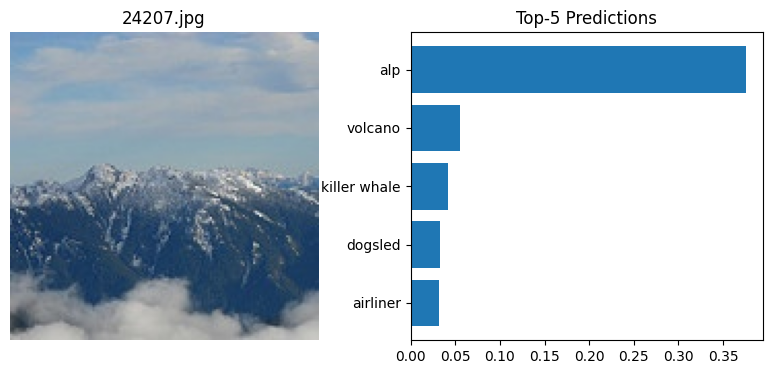

In [49]:
import matplotlib.pyplot as plt

img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Image
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title(img_name)

# Bar chart
classes = [p[0] for p in preds]
prob_values = [p[1] for p in preds]

axes[1].barh(classes, prob_values)
axes[1].invert_yaxis()
axes[1].set_title("Top-5 Predictions")

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

#  how would you adapt this kind of visualization for a dashboard that a non-technical 
# team member needs to review flagged predictions? 
# Answer:
# For a non-technical dashboard, the visualization should display only the primary
# prediction, accompanied by a clear visual indicator (e.g., green/red), rather
# than showing five bars.

# What threshold on the top-1 probability 
# might you use to decide when a prediction is "confident enough" to act on?
# Answer:
# A reasonable threshold for deeming a prediction "confident enough"
# would be a top-1 probability of >= 0.70; below this value, the prediction
# should be flagged for human review before any action is taken based upon it.